<a href="https://colab.research.google.com/github/CamJeff/COMP-551-Mini-Project-3/blob/main/Assign_4_All_BERT_Model_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import torch
from torch import nn
from transformers import DistilBertModel, DistilBertTokenizer
from keras.preprocessing.sequence import pad_sequences
from torch.utils.data import TensorDataset, DataLoader, SequentialSampler
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Processing the Dataset

**Read the Files:**

In [ ]:
# gain access to dataset files in the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# open the WOS file
x_file = open("/content/drive/My Drive/WOS11967/X.txt", "r")
raw_x = []

for entry in x_file:
  raw_x.append(entry.strip())

x_file.close()

y1_file = open("/content/drive/My Drive/WOS11967/YL1.txt", "r")
main_labels = []

for entry in y1_file:
  main_labels.append(int(entry.strip()))

y1_file.close()


y2_file = open("/content/drive/My Drive/WOS11967/YL2.txt", "r")
sub_labels = []

# convert YL2 entries to the 35 subclasses
counter = 0

for entry in y2_file:
  sub_labels.append(main_labels[counter]*5 + int(entry.strip()))

  counter +=1

y2_file.close()


**Create the Dataset for the Main Labels:**




In [ ]:
def assignEntries(label_entires, indices):
  features = []
  labels = []

  for i in indices:
    features.append(raw_x[i])
    labels.append(label_entires[i])

  return features, labels

# split the data into a train and test set
tot_entries = len(raw_x)
indices = range(tot_entries)

# create a large training set to fine tune the model for 1 epoch (80/20 split)
large_train_idx = random.sample(indices, (tot_entries*4)//5)
large_test_idx = [i for i in indices if not i in large_train_idx]

# create a medium training set to fine tune the model for 2 epoch (40/60 split)
med_train_idx = random.sample(indices, (tot_entries*2)//5)
med_test_idx = [i for i in indices if not i in med_train_idx]

# create a small training set to fine tune the model for 4 epoch (20/80 split)
small_train_idx = random.sample(indices, tot_entries//5)
small_test_idx = [i for i in indices if not i in small_train_idx]

# assign the correspondsing train entries to the features and labels list
large_train_x, large_train_y1  = assignEntries(main_labels, large_train_idx)
med_train_x, med_train_y1      = assignEntries(main_labels, med_train_idx)
small_train_x, small_train_y1  = assignEntries(main_labels, small_train_idx)

# same thing but for test entries
large_test_x, large_test_y1  = assignEntries(main_labels, large_test_idx)
med_test_x, med_test_y1      = assignEntries(main_labels, med_test_idx)
small_test_x, small_test_y1  = assignEntries(main_labels, small_test_idx)

In [ ]:
# tokenize where we cap each entry to 100 words for faster processing
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased', do_lower_case=True)

large_train_tokens = list(map(lambda t: ['[CLS]'] + tokenizer.tokenize(t)[:101] + ['[SEP]'], large_train_x))
large_test_tokens  =  list(map(lambda t: ['[CLS]'] + tokenizer.tokenize(t)[:101] + ['[SEP]'], large_test_x))

med_train_tokens = list(map(lambda t: ['[CLS]'] + tokenizer.tokenize(t)[:101] + ['[SEP]'], med_train_x))
med_test_tokens  =  list(map(lambda t: ['[CLS]'] + tokenizer.tokenize(t)[:101] + ['[SEP]'], med_test_x))

small_train_tokens = list(map(lambda t: ['[CLS]'] + tokenizer.tokenize(t)[:101] + ['[SEP]'], small_train_x))
small_test_tokens  =  list(map(lambda t: ['[CLS]'] + tokenizer.tokenize(t)[:101] + ['[SEP]'], small_test_x))

# embed the tokens
large_train_emb = pad_sequences(list(map(tokenizer.convert_tokens_to_ids, large_train_tokens)), maxlen=102, truncating="post", padding="post", dtype="int")
large_test_emb  = pad_sequences(list(map(tokenizer.convert_tokens_to_ids, large_test_tokens)), maxlen=102, truncating="post", padding="post", dtype="int")

med_train_emb = pad_sequences(list(map(tokenizer.convert_tokens_to_ids, med_train_tokens)), maxlen=102, truncating="post", padding="post", dtype="int")
med_test_emb  = pad_sequences(list(map(tokenizer.convert_tokens_to_ids, med_test_tokens)), maxlen=102, truncating="post", padding="post", dtype="int")

small_train_emb = pad_sequences(list(map(tokenizer.convert_tokens_to_ids, small_train_tokens)), maxlen=102, truncating="post", padding="post", dtype="int")
small_test_emb  = pad_sequences(list(map(tokenizer.convert_tokens_to_ids, small_test_tokens)), maxlen=102, truncating="post", padding="post", dtype="int")

# create attention masks
large_train_mask = [[float(i > 0) for i in j] for j in large_train_emb]
large_test_mask  = [[float(i > 0) for i in j] for j in large_test_emb]

med_train_mask = [[float(i > 0) for i in j] for j in med_train_emb]
med_test_mask  = [[float(i > 0) for i in j] for j in med_test_emb]

small_train_mask = [[float(i > 0) for i in j] for j in small_train_emb]
small_test_mask  = [[float(i > 0) for i in j] for j in small_test_emb]

# transform the data to tensor
large_train_x_tnsr   = torch.tensor(large_train_emb)
large_train_y1_tnsr  = torch.tensor(large_train_y1)
large_train_msk_tnsr = torch.tensor(large_train_mask)

med_train_x_tnsr   = torch.tensor(med_train_emb)
med_train_y1_tnsr  = torch.tensor(med_train_y1)
med_train_msk_tnsr = torch.tensor(med_train_mask)

small_train_x_tnsr   = torch.tensor(small_train_emb)
small_train_y1_tnsr  = torch.tensor(small_train_y1)
small_train_msk_tnsr = torch.tensor(small_train_mask)

# same thing for the test set
large_test_x_tnsr   = torch.tensor(large_test_emb)
large_test_y1_tnsr  = torch.tensor(large_test_y1)
large_test_msk_tnsr = torch.tensor(large_test_mask)

med_test_x_tnsr   = torch.tensor(med_test_emb)
med_test_y1_tnsr  = torch.tensor(med_test_y1)
med_test_msk_tnsr = torch.tensor(med_test_mask)

small_test_x_tnsr   = torch.tensor(small_test_emb)
small_test_y1_tnsr  = torch.tensor(small_test_y1)
small_test_msk_tnsr = torch.tensor(small_test_mask)


# package features, labels, and masks into a loader using the largest possible batch size given the RAM
large_train_set1  = TensorDataset(large_train_x_tnsr, large_train_msk_tnsr, large_train_y1_tnsr)
large_train_smp1  = SequentialSampler(large_train_set1)
large_train_load1 = DataLoader(large_train_set1, sampler=large_train_smp1, batch_size=16)

med_train_set1  = TensorDataset(med_train_x_tnsr, med_train_msk_tnsr, med_train_y1_tnsr)
med_train_smp1  = SequentialSampler(med_train_set1)
med_train_load1 = DataLoader(med_train_set1, sampler=med_train_smp1, batch_size=16)

small_train_set1  = TensorDataset(small_train_x_tnsr, small_train_msk_tnsr, small_train_y1_tnsr)
small_train_smp1  = SequentialSampler(small_train_set1)
small_train_load1 = DataLoader(small_train_set1, sampler=small_train_smp1, batch_size=16)

# same thing for the test set
large_test_set1  = TensorDataset(large_test_x_tnsr, large_test_msk_tnsr, large_test_y1_tnsr)
large_test_smp1  = SequentialSampler(large_test_set1)
large_test_load1 = DataLoader(large_test_set1, sampler=large_test_smp1, batch_size=16)

med_test_set1  = TensorDataset(med_test_x_tnsr, med_test_msk_tnsr, med_test_y1_tnsr)
med_test_smp1  = SequentialSampler(med_test_set1)
med_test_load1 = DataLoader(med_test_set1, sampler=med_test_smp1, batch_size=16)

small_test_set1  = TensorDataset(small_test_x_tnsr, small_test_msk_tnsr, small_test_y1_tnsr)
small_test_smp1  = SequentialSampler(small_test_set1)
small_test_load1 = DataLoader(small_test_set1, sampler=small_test_smp1, batch_size=16)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

# Task 2: Get the Bert Model and Fine Tune

In [ ]:
class ModifiedBert(nn.Module):
    def __init__(self, task, freeze=False):
        super(ModifiedBert, self).__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased', output_attentions=True)

        # only update the last layer to simplify fine tuning
        if (freeze):
          for name, param in self.bert.named_parameters():
            if "transformer.layer" in name and not "transformer.layer.5" in name:
                param.requires_grad = False

        if (task == "Y1"):
          self.linear = nn.Linear(self.bert.config.hidden_size, 7)
        elif (task == "Y2"):
          self.linear = nn.Linear(self.bert.config.hidden_size, 35)
        else:
          raise Exception("given invalid task")

        self.softmax = nn.Softmax(dim=1)


    def forward(self, embeds, masks=None):
        raw_output = self.bert(embeds, attention_mask=masks, output_attentions=True)

        # unpackage the output to get the last layer values
        last_layer = raw_output.last_hidden_state
        last_emb = last_layer[:, 0, :]

        # transform the output to a probability simplex
        linear_output = self.linear(last_emb)
        output = self.softmax(linear_output)

        # return results + attention matrices
        return output, raw_output.attentions


In [ ]:
# define our models
large_model_y1 = ModifiedBert("Y1", True)
med_model_y1   = ModifiedBert("Y1", True)
small_model_y1 = ModifiedBert("Y1", True)

# set the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# define how to evaluate the performance of the model
def eval_acc(model, loader, size, mini=False):
  model.eval()

  with torch.no_grad():
    test_acc  = 0.0

    for k, batch in enumerate(loader):
      torch.cuda.empty_cache()

      emb, mask, label = tuple(t.to(device) for t in batch)

      pred, _ = model(emb, mask)

      # count the number of TP
      test_acc += (pred.argmax(dim=1) == label).float().sum().item()

      # do a mini evaluation to quickly estimate the true test accuracy
      if (mini and k == 3):
        size = 4 * loader.batch_size
        break

  return test_acc / size


In [ ]:
# fine-tunning
loss_fn = nn.CrossEntropyLoss()
#optimizer = Adam(filter(lambda p: p.requires_grad, large_model_y1.parameters()), lr=2e-5) # made separate for each model

def fine_tune(model, train_loader, test_loader, optimizer, epoch):
  test_size = len(test_loader.dataset)
  test_acc  = []

  for i in range(epoch):
    model.train()

    for j, batch in enumerate(train_loader):
      # clear cache for each batch to limit the amount of RAM used
      torch.cuda.empty_cache()

      # set the data to GPU to match the model
      emb, mask, label = tuple(t.to(device) for t in batch)

      output, _ = model(emb, mask)
      loss      = loss_fn(output, label)

      # reset the accumulated change before doing backward prop
      model.zero_grad()
      loss.backward()
      optimizer.step()

      # check up on the fine tuning process
      if (j % 50 == 0):
        test_acc.append(eval_acc(model, test_loader, test_size, mini=True))
        print("Epoch: %d, Completed batch %d, Estimated Test Accurracy: %f" % (i, j, test_acc[-1]))

  # return the training history of the model
  return test_acc


# Task 3: Performance and Experiments

**Determine which Training Dataset Size Performs the Best on Y1 Task:**

In [ ]:
# train the model on a large training set for 1 epoch
large_model_y1.to(device)

large_opt1 = optimizer = Adam(filter(lambda p: p.requires_grad, large_model_y1.parameters()), lr=2e-5)

large_acc_curve = fine_tune(large_model_y1, large_train_load1, large_test_load1, large_opt1, epoch=1)

Epoch: 0, Completed batch 0, Estimated Test Accurracy: 0.125000
Epoch: 0, Completed batch 50, Estimated Test Accurracy: 0.390625
Epoch: 0, Completed batch 100, Estimated Test Accurracy: 0.593750
Epoch: 0, Completed batch 150, Estimated Test Accurracy: 0.687500
Epoch: 0, Completed batch 200, Estimated Test Accurracy: 0.750000
Epoch: 0, Completed batch 250, Estimated Test Accurracy: 0.781250
Epoch: 0, Completed batch 300, Estimated Test Accurracy: 0.750000
Epoch: 0, Completed batch 350, Estimated Test Accurracy: 0.765625
Epoch: 0, Completed batch 400, Estimated Test Accurracy: 0.781250
Epoch: 0, Completed batch 450, Estimated Test Accurracy: 0.796875
Epoch: 0, Completed batch 500, Estimated Test Accurracy: 0.828125
Epoch: 0, Completed batch 550, Estimated Test Accurracy: 0.859375


In [ ]:
# get the final result
test_size = len(large_test_load1.dataset)
large_y1_res = eval_acc(large_model_y1, large_test_load1, test_size)

History: [0.125, 0.390625, 0.59375, 0.6875, 0.75, 0.78125, 0.75, 0.765625, 0.78125, 0.796875, 0.828125, 0.859375]
Final Accuracy Result: 0.8036758563074352 



<Figure size 1200x480 with 0 Axes>

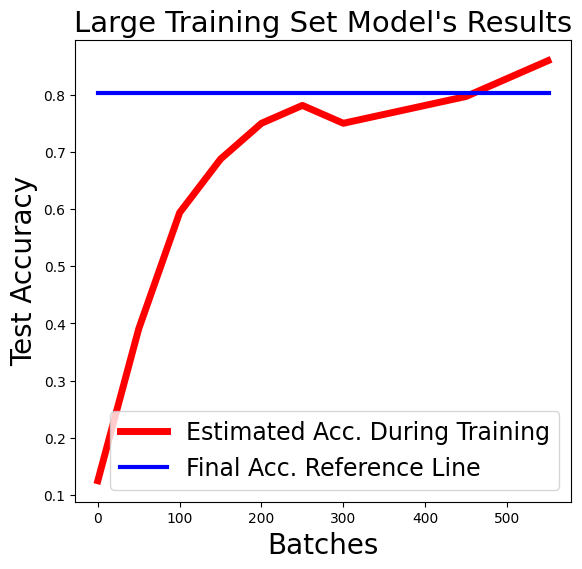

In [ ]:
# plot the training history + the final test accuracy for reference
print("History:", large_acc_curve)
print("Final Accuracy Result:", large_y1_res,'\n')

large_batches = range(0, 551, 50)

plt.figure().set_figwidth(12)
plt.figure().set_figheight(6)

plt.plot(large_batches, large_acc_curve, label = "Estimated Acc. During Training", color = 'r', linewidth = 5)
plt.plot([0,551], [large_y1_res, large_y1_res], label = "Final Acc. Reference Line", color = 'b', linewidth = 3)

plt.title("Large Training Set Model's Results", fontsize = 21)
plt.xlabel("Batches", fontsize = 20)
plt.ylabel("Test Accuracy", fontsize = 20)
plt.legend(fontsize = 17)

plt.show()


In [ ]:
# train the model on a medium training set for 2 epoch
med_model_y1.to(device)

med_opt1 = optimizer = Adam(filter(lambda p: p.requires_grad, med_model_y1.parameters()), lr=2e-5)

med_acc_curve = fine_tune(med_model_y1, med_train_load1, med_test_load1, med_opt1, epoch=2)

Epoch: 0, Completed batch 0, Estimated Test Accurracy: 0.062500
Epoch: 0, Completed batch 50, Estimated Test Accurracy: 0.484375
Epoch: 0, Completed batch 100, Estimated Test Accurracy: 0.468750
Epoch: 0, Completed batch 150, Estimated Test Accurracy: 0.671875
Epoch: 0, Completed batch 200, Estimated Test Accurracy: 0.718750
Epoch: 0, Completed batch 250, Estimated Test Accurracy: 0.734375
Epoch: 1, Completed batch 0, Estimated Test Accurracy: 0.750000
Epoch: 1, Completed batch 50, Estimated Test Accurracy: 0.828125
Epoch: 1, Completed batch 100, Estimated Test Accurracy: 0.796875
Epoch: 1, Completed batch 150, Estimated Test Accurracy: 0.765625
Epoch: 1, Completed batch 200, Estimated Test Accurracy: 0.796875
Epoch: 1, Completed batch 250, Estimated Test Accurracy: 0.828125


In [ ]:
# get the final result
test_size = len(med_test_load1.dataset)
med_y1_res = eval_acc(med_model_y1, med_test_load1, test_size)

History: [0.0625, 0.484375, 0.46875, 0.671875, 0.71875, 0.734375, 0.75, 0.828125, 0.796875, 0.765625, 0.796875, 0.828125]
Final Accuracy Result: 0.7955716474028687 



<Figure size 1200x480 with 0 Axes>

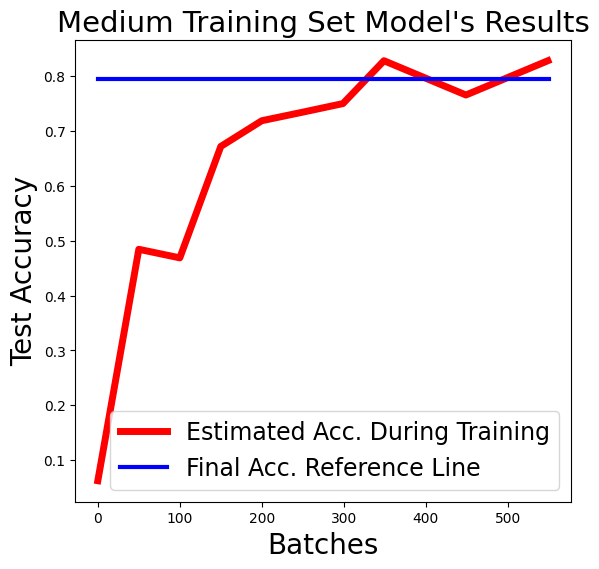

In [ ]:
# plot the training history + the final test accuracy for reference
print("History:", med_acc_curve)
print("Final Accuracy Result:", med_y1_res,'\n')

# get the batch axis ticks for the first epoch
med_batches = list(range(0, 251, 50))

# attach the batch axis ticks for the second epoch
train_size = len(med_train_load1.dataset) // 16
med_batches.extend(range(train_size, train_size+251, 50))

plt.figure().set_figwidth(12)
plt.figure().set_figheight(6)

plt.plot(med_batches, med_acc_curve, label = "Estimated Acc. During Training", color = 'r', linewidth = 5)
plt.plot([0,train_size+251], [med_y1_res, med_y1_res], label = "Final Acc. Reference Line", color = 'b', linewidth = 3)

plt.title("Medium Training Set Model's Results", fontsize = 21)
plt.xlabel("Batches", fontsize = 20)
plt.ylabel("Test Accuracy", fontsize = 20)
plt.legend(fontsize = 17)

plt.show()

In [ ]:
# train the model on a small training set for 4 epoch
small_model_y1.to(device)

small_opt1 = optimizer = Adam(filter(lambda p: p.requires_grad, small_model_y1.parameters()), lr=2e-5)

small_acc_curve = fine_tune(small_model_y1, small_train_load1, small_test_load1, small_opt1, epoch=4)

Epoch: 0, Completed batch 0, Estimated Test Accurracy: 0.125000
Epoch: 0, Completed batch 50, Estimated Test Accurracy: 0.265625
Epoch: 0, Completed batch 100, Estimated Test Accurracy: 0.640625
Epoch: 1, Completed batch 0, Estimated Test Accurracy: 0.640625
Epoch: 1, Completed batch 50, Estimated Test Accurracy: 0.625000
Epoch: 1, Completed batch 100, Estimated Test Accurracy: 0.671875
Epoch: 2, Completed batch 0, Estimated Test Accurracy: 0.687500
Epoch: 2, Completed batch 50, Estimated Test Accurracy: 0.703125
Epoch: 2, Completed batch 100, Estimated Test Accurracy: 0.718750
Epoch: 3, Completed batch 0, Estimated Test Accurracy: 0.765625
Epoch: 3, Completed batch 50, Estimated Test Accurracy: 0.781250
Epoch: 3, Completed batch 100, Estimated Test Accurracy: 0.765625


In [ ]:
# get the final result
test_size = len(small_test_load1.dataset)
small_y1_res = eval_acc(small_model_y1, small_test_load1, test_size)

History: [0.125, 0.265625, 0.640625, 0.640625, 0.625, 0.671875, 0.6875, 0.703125, 0.71875, 0.765625, 0.78125, 0.765625]
Final Accuracy Result: 0.7955922289534155 



<Figure size 1200x480 with 0 Axes>

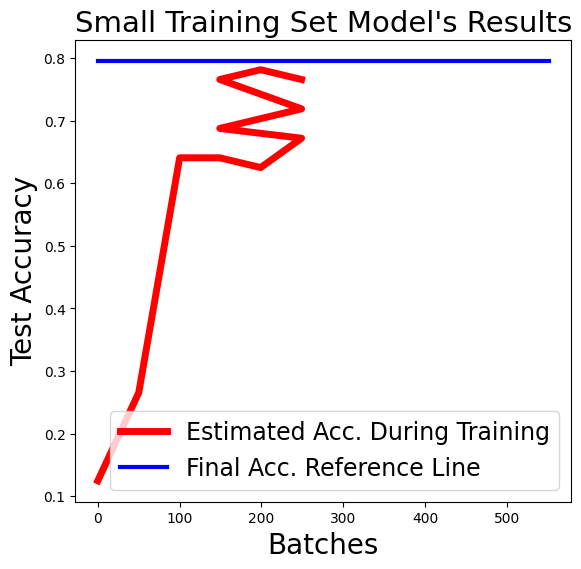

In [ ]:
# plot the training history + the final test accuracy for reference
print("History:", small_acc_curve)
print("Final Accuracy Result:", small_y1_res,'\n')

# get all the batch axis ticks
train_size = len(small_train_load1.dataset) // 16
small_batches = [0,50,100]
for i in range(3):
  small_batches.extend(range(train_size, train_size+101, 50))

plt.figure().set_figwidth(12)
plt.figure().set_figheight(6)

plt.plot(small_batches, small_acc_curve, label = "Estimated Acc. During Training", color = 'r', linewidth = 5)
plt.plot([0,551], [small_y1_res, small_y1_res], label = "Final Acc. Reference Line", color = 'b', linewidth = 3)

plt.title("Small Training Set Model's Results", fontsize = 21)
plt.xlabel("Batches", fontsize = 20)
plt.ylabel("Test Accuracy", fontsize = 20)
plt.legend(fontsize = 17)

plt.show()

**Based on the Previous Experiement, Train the Y2 Model on the Large Training Dataset:**



In [ ]:
# create the dataset for the y2 labels
_, large_train_y2  = assignEntries(sub_labels, large_train_idx)
_, large_test_y2  = assignEntries(sub_labels, large_test_idx)

# transform to tensor
large_train_y2_tnsr  = torch.tensor(large_train_y2)
large_test_y2_tnsr  = torch.tensor(large_test_y2)

# package features, labels, and masks into a loader
large_train_set2  = TensorDataset(large_train_x_tnsr, large_train_msk_tnsr, large_train_y2_tnsr)
large_train_smp2  = SequentialSampler(large_train_set2)
large_train_load2 = DataLoader(large_train_set2, sampler=large_train_smp2, batch_size=16)

# same thing for the test set
large_test_set2  = TensorDataset(large_test_x_tnsr, large_test_msk_tnsr, large_test_y2_tnsr)
large_test_smp2  = SequentialSampler(large_test_set2)
large_test_load2 = DataLoader(large_test_set2, sampler=large_test_smp2, batch_size=16)


In [ ]:
# define model + optimizer
large_model_y2 = ModifiedBert("Y2", True)

large_model_y2.to(device)

large_opt2 = optimizer = Adam(filter(lambda p: p.requires_grad, large_model_y2.parameters()), lr=2e-5)

In [ ]:
# fine tune
large_acc_curve2 = fine_tune(large_model_y2, large_train_load2, large_test_load2, large_opt2, epoch=1)

Epoch: 0, Completed batch 0, Estimated Test Accurracy: 0.031250
Epoch: 0, Completed batch 50, Estimated Test Accurracy: 0.031250
Epoch: 0, Completed batch 100, Estimated Test Accurracy: 0.078125
Epoch: 0, Completed batch 150, Estimated Test Accurracy: 0.218750
Epoch: 0, Completed batch 200, Estimated Test Accurracy: 0.296875
Epoch: 0, Completed batch 250, Estimated Test Accurracy: 0.281250
Epoch: 0, Completed batch 300, Estimated Test Accurracy: 0.343750
Epoch: 0, Completed batch 350, Estimated Test Accurracy: 0.390625
Epoch: 0, Completed batch 400, Estimated Test Accurracy: 0.468750
Epoch: 0, Completed batch 450, Estimated Test Accurracy: 0.484375
Epoch: 0, Completed batch 500, Estimated Test Accurracy: 0.531250
Epoch: 0, Completed batch 550, Estimated Test Accurracy: 0.531250


In [ ]:
# get the final result
test_size = len(large_test_load2.dataset)
large_y2_res = eval_acc(large_model_y2, large_test_load2, test_size)

History: [0.03125, 0.03125, 0.078125, 0.21875, 0.296875, 0.28125, 0.34375, 0.390625, 0.46875, 0.484375, 0.53125, 0.53125]
Final Accuracy Result: 0.46115288220551376 



<Figure size 1200x480 with 0 Axes>

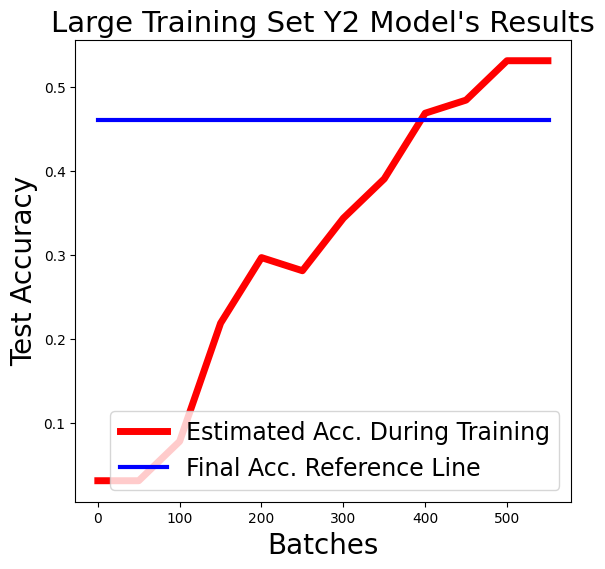

In [ ]:
# plot the training history + the final test accuracy for reference
print("History:", large_acc_curve2)
print("Final Accuracy Result:", large_y2_res,'\n')

plt.figure().set_figwidth(12)
plt.figure().set_figheight(6)

plt.plot(range(0,551,50), large_acc_curve2, label = "Estimated Acc. During Training", color = 'r', linewidth = 5)
plt.plot([0,551], [large_y2_res, large_y2_res], label = "Final Acc. Reference Line", color = 'b', linewidth = 3)

plt.title("Large Training Set Y2 Model's Results", fontsize = 21)
plt.xlabel("Batches", fontsize = 20)
plt.ylabel("Test Accuracy", fontsize = 20)
plt.legend(fontsize = 17)

plt.show()


**Observe the Attention Matrices from the Large Y1 and Y2 Models:**

In [ ]:
def getLastAttention(model, emb, mask, label):
  model.eval()

  with torch.no_grad():
    # unsqueeze() so the model is happy with the shape of emb
    output, attn = model(emb.unsqueeze(0), mask)

    # notifies if the input was correctly classified
    correct_pred = (output.argmax(dim=1) == label)

  return attn[-1][0].cpu(), correct_pred


In [ ]:
# collect the attention matrices of correctly and incorrectly clasified tokens
def collectSample(model, loader, smp_size = 2):
  correct_smp = []
  incorrect_smp = []
  n = 0
  m = 0

  for batch in loader:
    emb, mask, label = tuple(t.to(device) for t in batch)

    for i in range(16):
      attn, status = getLastAttention(model, emb[i], mask[i], label[i])
      token = tokenizer.convert_ids_to_tokens(emb[i])

      # sort the prediction
      if (status): # correctly predicted
        if (n < 2):
          correct_smp.append((attn,token))
          n += 1

      else: # incorrectly predicted
        if (m < 2):
            incorrect_smp.append((attn,token))
        m += 1

      # check if we gathered enough entires
      if (n >= 2 and m >= 2):
        return correct_smp, incorrect_smp



In [ ]:
# plots the [CLS] attention row with the specified head
def plotLastAttn(attn, tokens, head_idx):
  plt.figure(figsize=(12,1))

  # get the [CLS] row from the attention
  row = attn[head_idx][0].numpy().reshape(1,-1)

  sns.heatmap(row, xticklabels=tokens, yticklabels=["[CLS]"], cmap="viridis", cbar=True)

  plt.title("[CLS] Row from the Last Attention with Head %d" % (head_idx))

  plt.xticks(fontsize=8)
  plt.yticks(fontsize=10)

  plt.tight_layout()

  plt.show()



**Y1 Model Attention Plots:**

In [ ]:
# get our sample
good_Y1, bad_Y1 = collectSample(large_model_y1, large_test_load1)

/tmp/ipython-input-1031927571.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


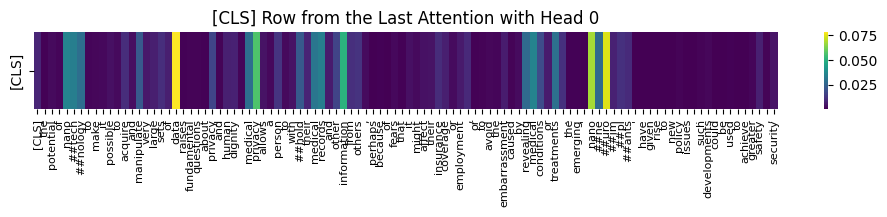

In [ ]:
# plot the first correct attention with head 0
correct1 = good_Y1[0]
plotLastAttn(correct1[0],correct1[1], 0)

/tmp/ipython-input-1031927571.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


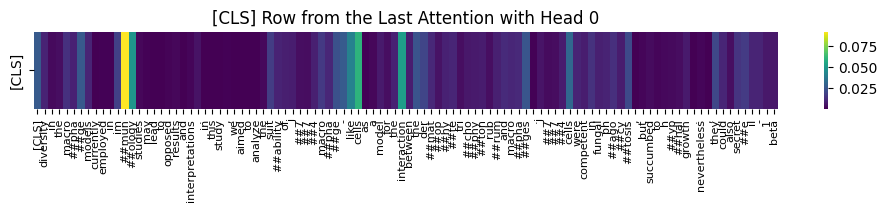

In [ ]:
# plot the second correct attention with head 0
correct2 = good_Y1[1]
plotLastAttn(correct2[0],correct2[1], 0)

/tmp/ipython-input-1031927571.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


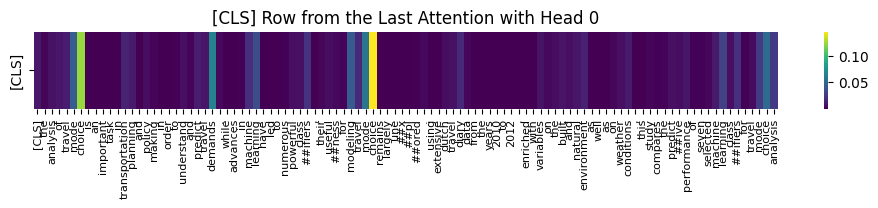

In [ ]:
# plot the first incorrect attention with head 0
incorrect1 = bad_Y1[0]
plotLastAttn(incorrect1[0],incorrect1[1], 0)

/tmp/ipython-input-1031927571.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


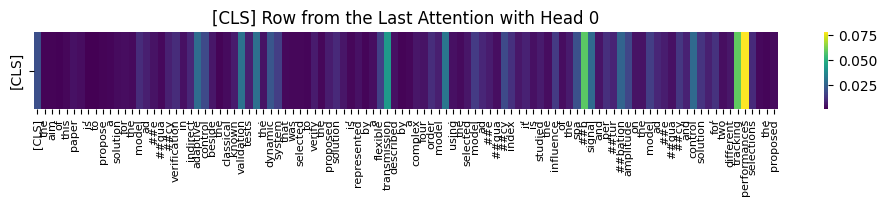

In [ ]:
# plot the second incorrect attention with head 0
incorrect2 = bad_Y1[1]
plotLastAttn(incorrect2[0],incorrect2[1], 0)

**Y2 Model Attention Plots:**

In [ ]:
# get our sample
good_Y2, bad_Y2 = collectSample(large_model_y2, large_test_load2)

/tmp/ipython-input-4228793779.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


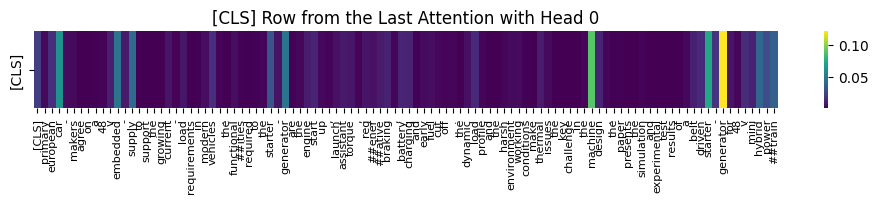

In [ ]:
# plot the first correct attention with head 0
correct1 = good_Y2[0]
plotLastAttn(correct1[0],correct1[1], 0)

/tmp/ipython-input-4228793779.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


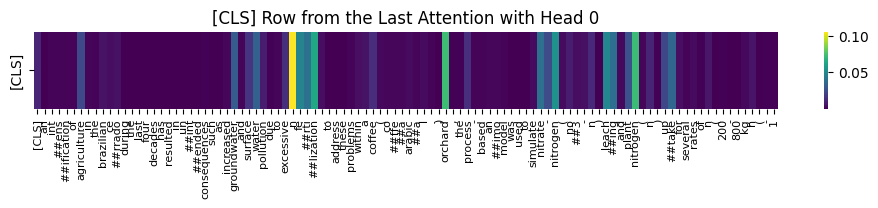

In [ ]:
# plot the second correct attention with head 0
correct2 = good_Y2[1]
plotLastAttn(correct2[0],correct2[1], 0)

/tmp/ipython-input-4228793779.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


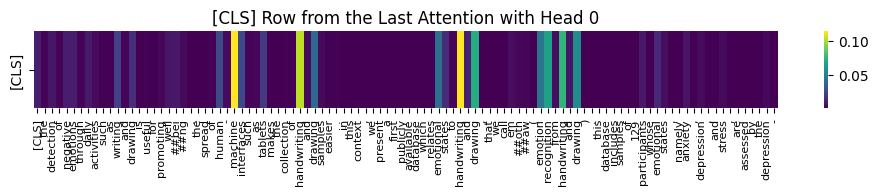

In [ ]:
# plot the first incorrect attention with head 0
incorrect1 = bad_Y2[0]
plotLastAttn(incorrect1[0],incorrect1[1], 0)

/tmp/ipython-input-4228793779.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


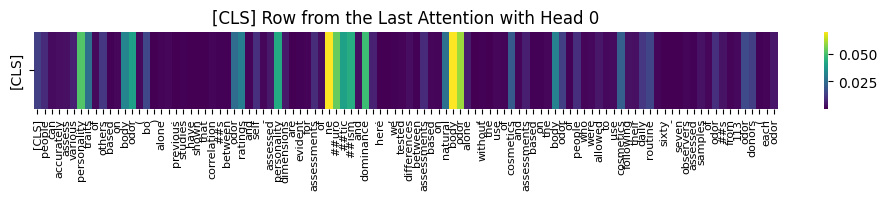

In [ ]:
# plot the second incorrect attention with head 0
incorrect2 = bad_Y2[1]
plotLastAttn(incorrect2[0],incorrect2[1], 0)